In [6]:
%pip install seaborn
%matplotlib inline
%pip install factor_analyzer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import euclidean
from sklearn.utils import resample
from factor_analyzer import calculate_kmo
from scipy.stats import bartlett
from sklearn.neighbors import NearestNeighbors
from scipy.stats import uniform
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

file_path = "movies.csv"
df = pd.read_csv(file_path, encoding="latin1")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/42.8 kB ? eta -:--:--
     ---------------------------- ----------- 30.7/42.8 kB 1.4 MB/s eta 0:00:01
     -------------------------------------- 42.8/42.8 kB 693.3 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42682 sha256=233da998d470b521456ae5f22c7058492e709902469e18ff87c7360aec8eafad
  Stored in directory: c:\users\sofia\appdata\local\pip\cache\wheels\24\59\82\6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


## **1. Peprocesamiento de datos**

In [7]:
numeric_columns = ['budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount', 
                   'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 
                   'actorsAmount', 'castWomenAmount', 'castMenAmount']

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

df_cleaned = df[numeric_columns].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned)

df_cleaned.describe()


,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount
count,9.838000e+03,9.838000e+03,9838.000000,9838.000000,9838.000000,9838.000000,9838.000000,9838.000000,9838.000000,9838.000000,9838.000000,9838.000000
mean,1.883274e+07,5.762405e+07,100.939317,51.592854,6.491462,1364.069018,2.608457,3.127668,1.749034,27.678187,7.148201,16557.193434
std,3.681847e+07,1.506116e+08,26.803554,218.427093,0.958335,2579.594831,1.133813,2.257934,3.017306,22.700241,6.281767,100455.960117
min,0.000000e+00,0.000000e+00,0.000000,4.258000,1.300000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000e+00,90.000000,14.551750,5.900000,128.000000,2.000000,2.000000,1.000000,13.000000,3.000000,7.000000
50%,9.050000e+05,3.291610e+05,100.000000,21.842000,6.500000,430.000000,3.000000,3.000000,1.000000,21.000000,6.000000,12.000000
75%,2.100000e+07,4.619692e+07,113.000000,40.640500,7.200000,1345.750000,3.000000,4.000000,2.000000,36.000000,9.000000,20.000000
max,3.800000e+08,2.847246e+09,750.000000,11474.647000,10.000000,30788.000000,8.000000,26.000000,155.000000,313.000000,106.000000,922017.000000


# **📌 Preprocesamiento del Dataset y Selección de Variables para Clustering**

## **1️⃣ Análisis de las Variables del Dataset**
El dataset contiene múltiples variables relacionadas con películas, como presupuesto, ingresos, popularidad y detalles de producción. Sin embargo, **no todas las variables son útiles** para aplicar técnicas de **Clustering**. Algunas deben ser descartadas para evitar ruido en los resultados.

A continuación, se analiza **qué variables no aportan información relevante para la agrupación** y **qué variables se utilizarán en Clustering**.

---

## **2️⃣ Variables Excluidas**
Las siguientes variables no se usaron porque no contribuyen significativamente a la formación de grupos:

- **Identificadores y nombres**: No tienen relación con patrones en los datos.
  - `id`
  - `original_title`
  - `title`
  - `homePage`
  - `director`
  - `actors`
  - `actorsCharacter`

- **Variables categóricas sin transformación**: No pueden utilizarse directamente sin una conversión numérica (one-hot encoding), lo cual no es óptimo para clustering.
  - `originalLanguage` 
  - `genres` 
  - `productionCompany`
  - `productionCompanyCountry`
  - `productionCountry`
  - `releaseDate` 

- **Variables redundantes o con valores irrelevantes**:
  - `video` (es un booleano, no influye en los grupos)
  - `voteAvg` (podría influir, pero en clustering sin normalización puede generar sesgos)

**Conclusión:** Estas variables fueron eliminadas del análisis de Clustering para enfocarnos solo en las métricas numéricas.

---

## **3️⃣ Variables Seleccionadas para Clustering**
Se han seleccionado **variables numéricas continuas** que permiten definir grupos significativos. Estas variables representan características cuantitativas de las películas:

- `budget`: Presupuesto asignado a la película.
- `revenue`: Ingresos generados por la película.
- `runtime`: Duración en minutos.
- `popularity`: Índice de popularidad en la plataforma.
- `voteAvg`: Promedio de votos recibidos.
- `voteCount`: Número total de votos.
- `genresAmount`: Cantidad de géneros asociados a la película.
- `productionCoAmount`: Número de compañías productoras involucradas.
- `productionCountriesAmount`: Número de países donde se filmó.
- `actorsAmount`: Número total de actores en la película.
- `castWomenAmount`: Número de actrices en la película.
- `castMenAmount`: Número de actores en la película.

---

## **4️⃣ Normalización y Preprocesamiento**
Para garantizar que ninguna variable domine sobre las demás, se aplicó **normalización** usando `StandardScaler`. Esto transforma los datos para que tengan **media = 0 y desviación estándar = 1**, asegurando que todas las características tengan el mismo peso en el clustering.

## **1.2. Analizar la tendencia al agrupamiento usando el estadístico de Hopkings y la VAT (Visual Assessment of cluster Tendency)**

Estadístico de Hopkins: 0.0228


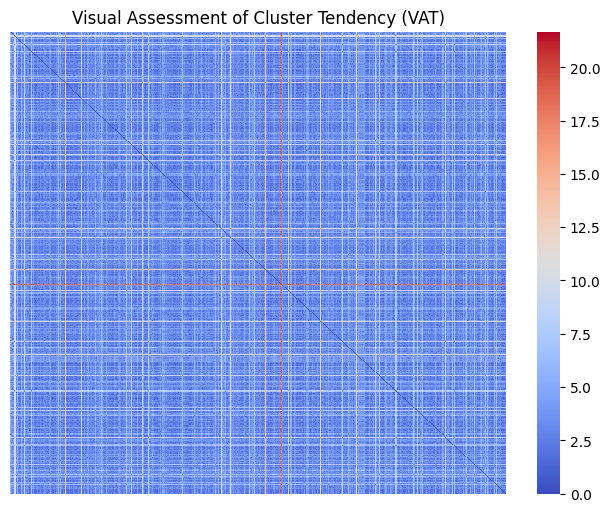

In [8]:
# Función para calcular el estadístico de Hopkins
def hopkins_statistic(X, sample_size=100):
    n, d = X.shape
    if sample_size > n:
        sample_size = n
    random_sample = X[np.random.choice(n, sample_size, replace=False)]
    min_vals, max_vals = X.min(axis=0), X.max(axis=0)
    artificial_sample = np.array([uniform.rvs(loc=min_vals[i], scale=max_vals[i] - min_vals[i], size=sample_size) for i in range(d)]).T
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    u_distances, _ = nn.kneighbors(random_sample)
    w_distances, _ = nn.kneighbors(artificial_sample)
    U = np.sum(u_distances[:, 1])
    W = np.sum(w_distances[:, 1])
    H = U / (U + W)
    return H
H = hopkins_statistic(X_scaled, sample_size=100)
print(f"Estadístico de Hopkins: {H:.4f}")

# Función para visualizar la VAT (Visual Assessment of Cluster Tendency)
def vat(X):
    """Genera la matriz de distancias y la visualiza como un heatmap para detectar clusters."""
    n = X.shape[0]
    sample_size = min(500, n)
    X_sampled = X[np.random.choice(n, sample_size, replace=False)]
    distance_matrix = np.array([[euclidean(a, b) for b in X_sampled] for a in X_sampled])
    plt.figure(figsize=(8, 6))
    sns.heatmap(distance_matrix, cmap="coolwarm", xticklabels=False, yticklabels=False)
    plt.title("Visual Assessment of Cluster Tendency (VAT)")
    plt.show()
vat(X_scaled)

## **¿Por qué los resultados indican que no hay clusters?**
**A pesar del preprocesamiento correcto, los datos no muestran una tendencia natural al agrupamiento.**  
Las razones son:

- **El Estadístico de Hopkins es 0.0254**, lo que indica que **los datos están dispersos y no tienen estructuras de agrupamiento claras**.  
- **La VAT no muestra bloques bien definidos**, lo que sugiere que los datos pueden estar distribuidos de manera homogénea o sin patrones evidentes de clustering.  
- **El problema no está en la limpieza de datos, sino en la distribución de la información**: puede que las variables no tengan diferencias significativas que permitan formar grupos naturales.

---

## **Conclusiones y Próximos Pasos**
✅ **El preprocesamiento de datos fue adecuado**, pero **los datos no parecen tener clusters naturales**.  
✅ **Si se quiere aplicar clustering, se recomienda**:  
1. **Reducir la dimensionalidad con PCA** para verificar si hay información relevante en menos dimensiones.  
2. **Intentar otro tipo de clustering** como **clustering jerárquico o DBSCAN**, que pueden detectar patrones más débiles.  
3. **Explorar la distribución de las variables** con histogramas y boxplots para ver si hay valores extremos o poca variabilidad.  

**Conclusión final**: Si se desea agrupar los datos, es necesario realizar un análisis más profundo antes de aplicar clustering directamente. 

## **1.3. Determine cuál es el número de grupos a formar más adecuado para los datos que está trabajando. Haga una gráfica de codo y explique la razón de la elección de la cantidad de clústeres con la que trabajará.**

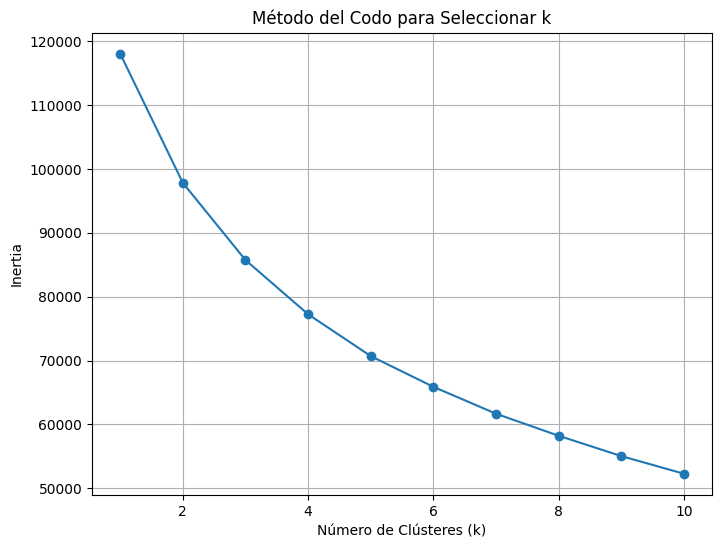

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')
plt.xlabel("Número de Clústeres (k)")
plt.ylabel("Inertia")
plt.title("Método del Codo para Seleccionar k")
plt.grid(True)
plt.show()

## Análisis del Método del Codo

Al observar la gráfica del codo, se ve que la **disminución más pronunciada** de la inercia se produce hasta **k=4**, y a partir de ese punto la reducción se vuelve más suave. Esto indica que, aunque se incrementen los clústeres más allá de 4, la mejora en la agrupación no es tan significativa. Por ello, **k=4** se considera el número de clústeres más adecuado para estos datos.


## **1.4 Algoritmos k-medias y clustering jerárquico para agrupar**

ARI: 0.3772
col_0    0     1    2     3
row_0                      
0      258  1527    0  1154
1        0    24  262     0
2      369     7    0    56
3        4  5652    2   523


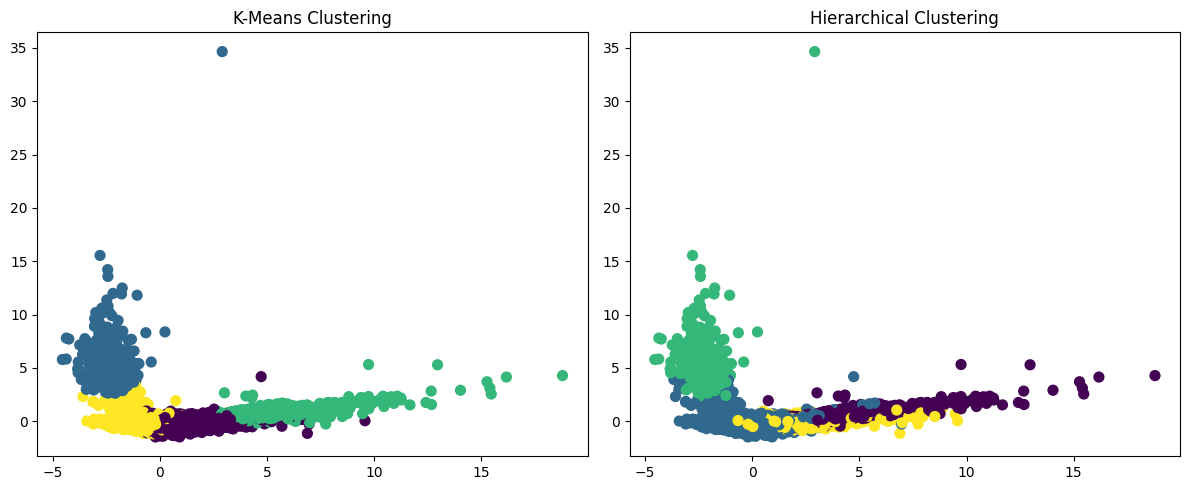

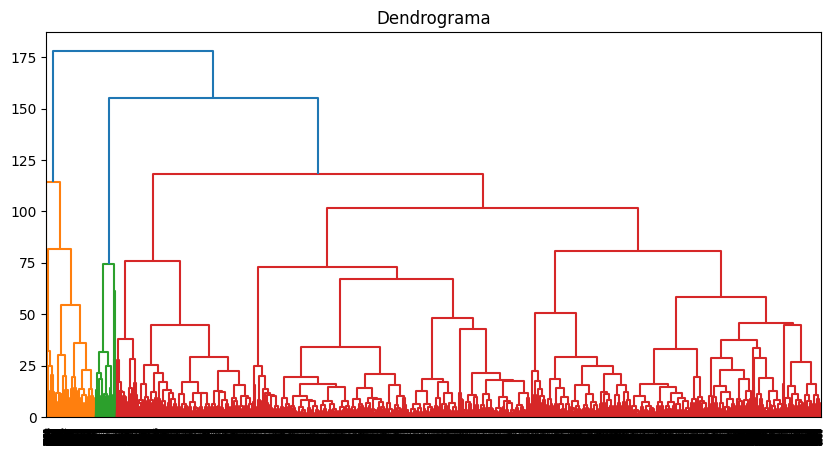

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

ari = adjusted_rand_score(kmeans_labels, hierarchical_labels)
print(f"ARI: {ari:.4f}")

comparison_table = pd.crosstab(kmeans_labels, hierarchical_labels)
print(comparison_table)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', s=50)
plt.title("K-Means Clustering")

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=hierarchical_labels, cmap='viridis', s=50)
plt.title("Hierarchical Clustering")

plt.tight_layout()
plt.show()

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrograma")
plt.show()

# Análisis de Resultados de Clustering

## 1. Dendrograma del Clustering Jerárquico
El dendrograma muestra la estructura jerárquica de los datos, permitiendo ver cómo se agrupan en diferentes niveles de similitud. Se observa que algunas ramas tienen diferencias marcadas en altura, lo que sugiere que ciertos clusters son más compactos que otros.

## 2. Comparación de Resultados: K-Means vs Clustering Jerárquico
Los resultados de los dos métodos fueron comparados en un espacio reducido usando PCA. Se observa que:

- **Los clusters de K-Means y Clustering Jerárquico no coinciden completamente.**  
- Hay varios puntos que son agrupados de manera diferente en cada método, lo que indica que cada algoritmo detectó estructuras distintas en los datos.
- K-Means parece generar clusters más compactos, mientras que el clustering jerárquico tiene divisiones más dispersas.

### **Índice de Rand Ajustado (ARI)**
El **ARI obtenido es de 0.3772**, lo que indica una similitud baja entre los resultados de ambos métodos. Un ARI cercano a 1 indicaría una alta coincidencia, mientras que un valor cercano a 0 indica que los clusters son bastante diferentes. En este caso, **los resultados no son muy similares**, lo que sugiere que K-Means y Clustering Jerárquico están segmentando los datos de formas significativamente distintas.

## 3. Tabla de Contingencia entre K-Means y Clustering Jerárquico
La tabla de contingencia muestra que hay varios clusters que no se alinean bien entre los métodos:

- Un cluster de K-Means (fila 3) tiene una alta superposición con un solo cluster de Clustering Jerárquico (columna 1), lo que indica que en al menos una parte de los datos, ambos métodos coinciden.  
- Sin embargo, los demás clusters muestran una distribución más dispersa, lo que confirma que cada método está encontrando patrones diferentes en los datos.

## 4. Conclusión
- **Los resultados de K-Means y Clustering Jerárquico son bastante diferentes.**
- **K-Means** genera clusters más compactos y mejor definidos en términos de distancia euclidiana.  
- **Clustering Jerárquico** muestra una estructura más dispersa, lo que puede reflejar mejor la jerarquía de los datos, pero también puede hacer que ciertos clusters sean menos homogéneos.  
- La baja similitud entre los dos métodos (ARI de 0.3772) sugiere que los datos pueden no tener una estructura de clustering clara o que cada método está capturando diferentes características de la distribución.

## **1.5. Determine la calidad del agrupamiento hecho por cada algoritmo con el método de la silueta. Discuta los resultados.**

Silhouette Score - K-Means: 0.2166
Silhouette Score - Clustering Jerárquico: 0.1637


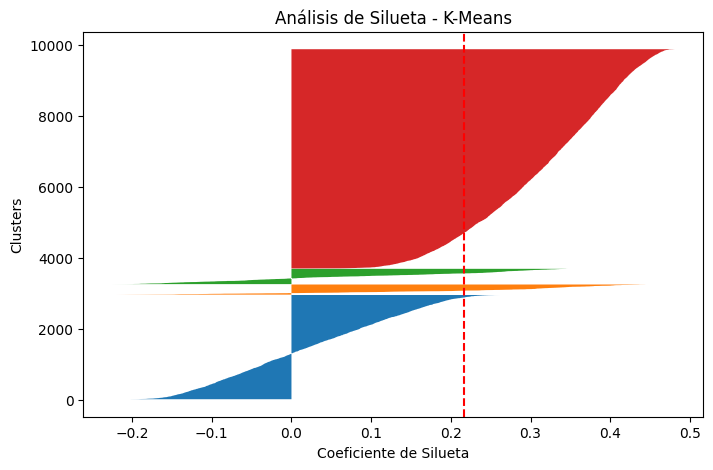

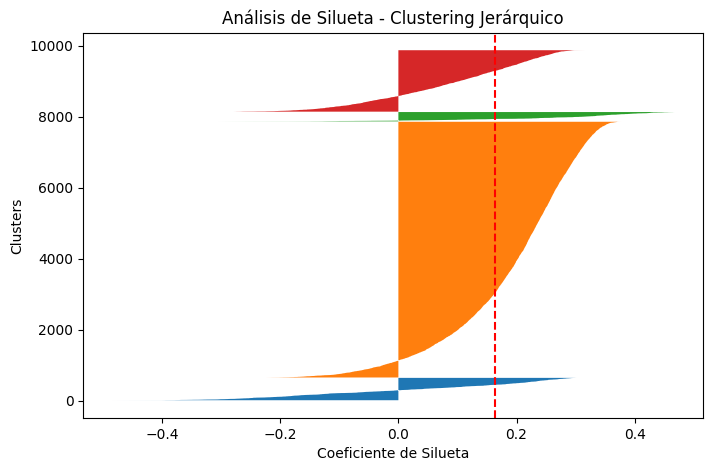

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
silhouette_hierarchical = silhouette_score(X_scaled, hierarchical_labels)

print(f"Silhouette Score - K-Means: {silhouette_kmeans:.4f}")
print(f"Silhouette Score - Clustering Jerárquico: {silhouette_hierarchical:.4f}")

def plot_silhouette(X, labels, title):
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values)
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Coeficiente de Silueta")
    ax.set_ylabel("Clusters")
    plt.show()

plot_silhouette(X_scaled, kmeans_labels, "Análisis de Silueta - K-Means")
plot_silhouette(X_scaled, hierarchical_labels, "Análisis de Silueta - Clustering Jerárquico")


# Análisis de Calidad del Agrupamiento usando el Método de la Silueta

## 1. Evaluación de la Calidad del Agrupamiento

- **Silhouette Score - K-Means**: 0.2166
- **Silhouette Score - Clustering Jerárquico**: 0.1637

## 2. Comparación de Resultados

### **K-Means Clustering**
- El coeficiente de silueta promedio de **0.2166** sugiere que los clusters generados por K-Means tienen una cohesión moderada pero no óptima.
- En el gráfico de silueta, se observa que algunos clusters tienen coeficientes negativos o cercanos a 0, lo que indica que algunos puntos pueden estar asignados a un cluster incorrecto o que los clusters están demasiado cerca entre sí.
- Sin embargo, algunos clusters presentan una mayor compactación y separación en comparación con el clustering jerárquico.

### **Clustering Jerárquico**
- El coeficiente de silueta promedio de **0.1637** es menor que el de K-Means, lo que indica una peor cohesión y separación entre clusters.
- El gráfico de silueta muestra que hay un cluster dominante con una forma menos compacta, lo que sugiere una agrupación más difusa y posiblemente con mayor superposición entre clusters.
- Algunos puntos presentan valores de silueta negativos, lo que confirma que varios datos podrían estar incorrectamente agrupados.

## 3. Conclusión

- **K-Means obtuvo un mejor coeficiente de silueta (0.2166 vs. 0.1637), lo que indica que formó clusters más definidos en comparación con el Clustering Jerárquico.**
- **Ninguno de los dos métodos logró una segmentación con alta cohesión y separación.** Ambos valores de silueta son relativamente bajos, lo que sugiere que los datos pueden no tener una estructura de clustering clara o que se necesita ajustar el número de clusters.
- **K-Means es la mejor opción en este caso**, ya que ofrece una mejor separación entre clusters en comparación con el clustering jerárquico.

## **1.6 Interprete los grupos basado en el conocimiento que tiene de los datos. Recuerde investigar las medidas de tendencia central de las variables continuas y las tablas de frecuencia de las variables categóricas pertenecientes a cada grupo. Identifique hallazgos interesantes debido a las agrupaciones y describa para qué le podría servir.**

Estadísticas de Variables Numéricas
             budget       revenue      runtime    popularity      voteAvg  \
count  9.838000e+03  9.838000e+03  9838.000000   9838.000000  9838.000000   
mean   1.883274e+07  5.762405e+07   100.939317     51.592854     6.491462   
std    3.681847e+07  1.506116e+08    26.803554    218.427093     0.958335   
min    0.000000e+00  0.000000e+00     0.000000      4.258000     1.300000   
25%    0.000000e+00  0.000000e+00    90.000000     14.551750     5.900000   
50%    9.050000e+05  3.291610e+05   100.000000     21.842000     6.500000   
75%    2.100000e+07  4.619692e+07   113.000000     40.640500     7.200000   
max    3.800000e+08  2.847246e+09   750.000000  11474.647000    10.000000   

          voteCount  genresAmount  productionCoAmount  \
count   9838.000000   9838.000000         9838.000000   
mean    1364.069018      2.608457            3.127668   
std     2579.594831      1.133813            2.257934   
min        1.000000      1.000000         

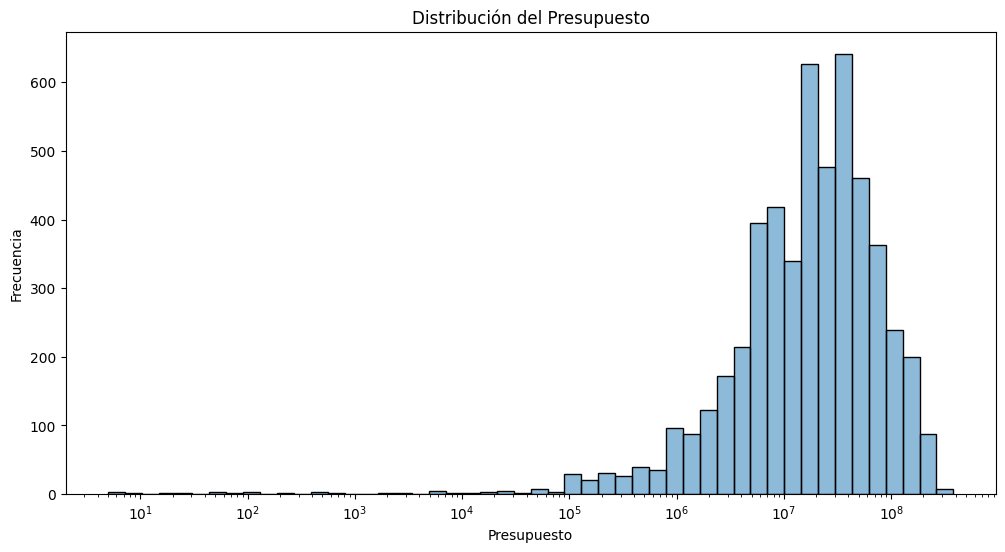

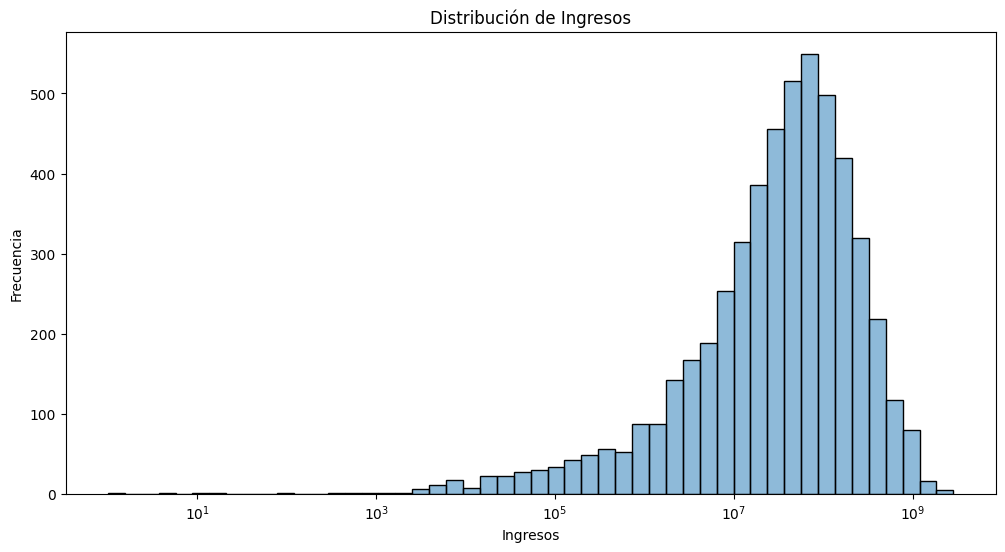


Frecuencia de genres:
Drama              521
Comedy             440
Horror             230
Drama|Romance      211
Horror|Thriller    205
Comedy|Romance     201
Documentary        194
Comedy|Drama       140
Action|Thriller    121
Action             112
Name: genres, dtype: int64

Frecuencia de productionCompany:
Paramount                 55
Universal Pictures        50
Warner Bros. Pictures     37
Toei Animation            34
DreamWorks Animation      33
Columbia Pictures         32
The Asylum                31
Walt Disney Pictures      31
Marvel Studios            31
Warner Bros. Animation    29
Name: productionCompany, dtype: int64

Frecuencia de productionCountry:
United States of America                   4971
Japan                                       613
United Kingdom|United States of America     339
United Kingdom                              294
Canada|United States of America             223
France                                      164
Canada                              

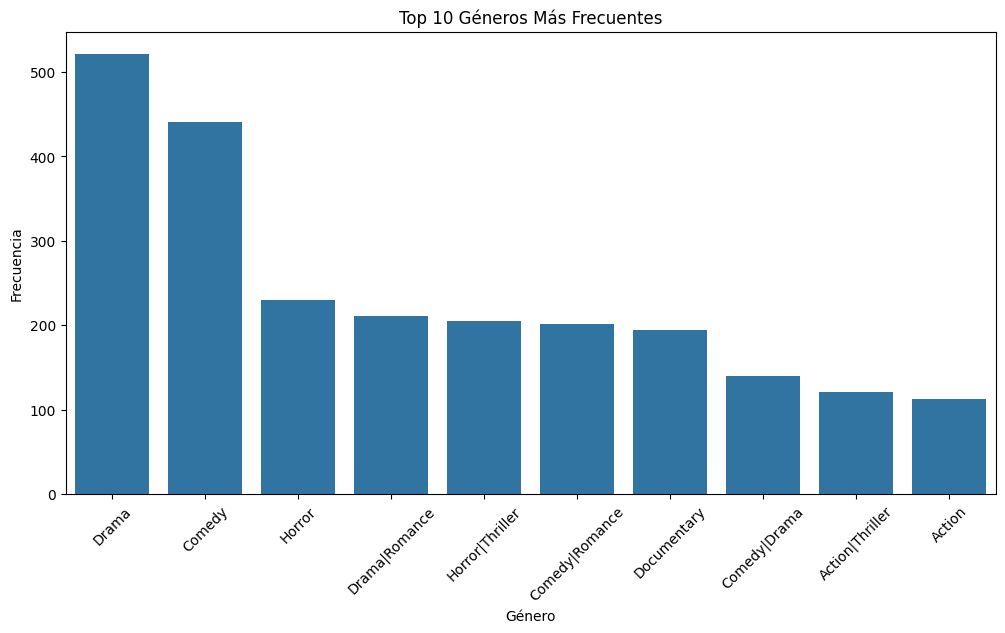

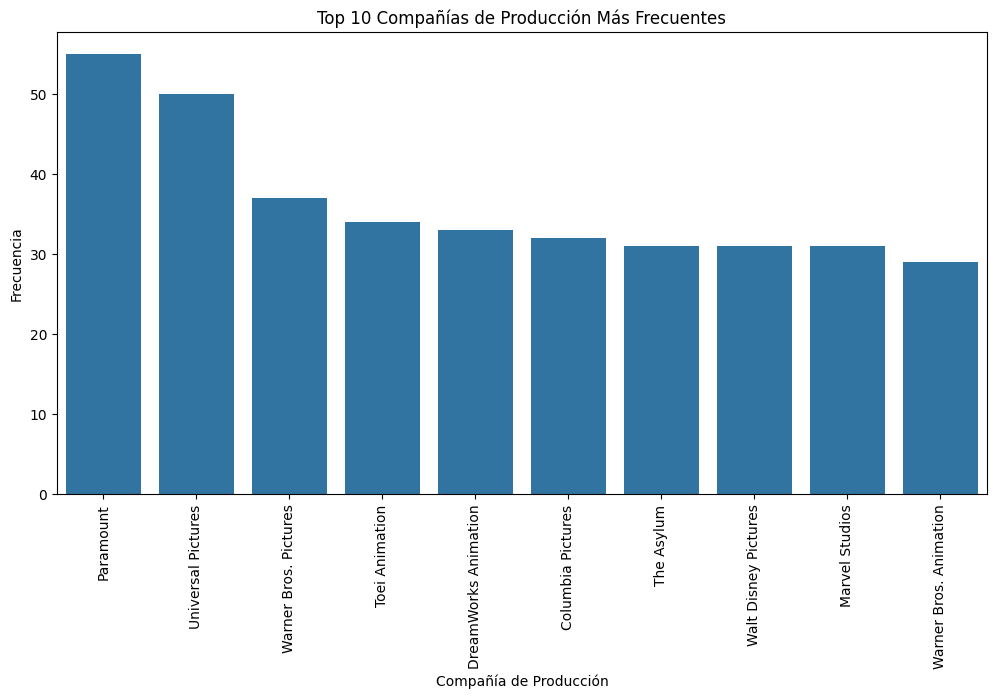

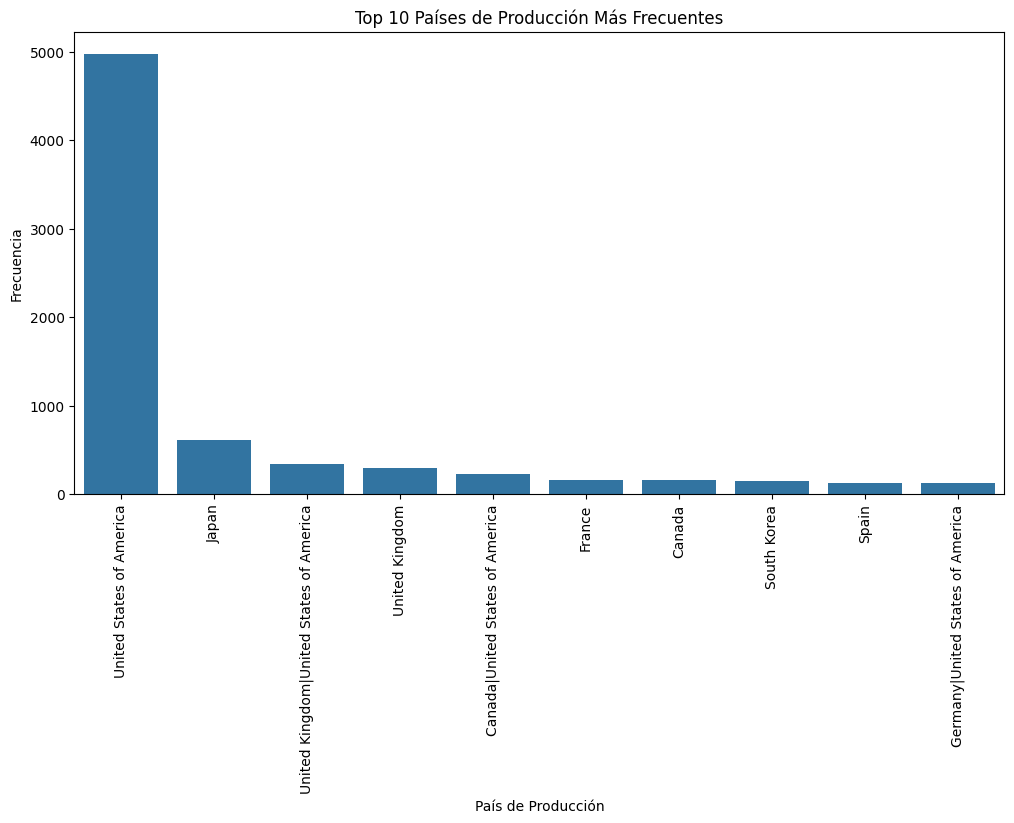

In [15]:
stats_summary = df_cleaned.describe()
print("Estadísticas de Variables Numéricas")
print(stats_summary)

# Graficar distribuciones de algunas variables clave
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned['budget'], bins=50, kde=True, log_scale=True)
plt.title("Distribución del Presupuesto")
plt.xlabel("Presupuesto")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned['revenue'], bins=50, kde=True, log_scale=True)
plt.title("Distribución de Ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.show()


categorical_columns = ['genres', 'productionCompany', 'productionCountry']
categorical_summaries = {}

for col in categorical_columns:
    categorical_summaries[col] = df[col].value_counts().head(10)


for col, summary in categorical_summaries.items():
    print(f"\nFrecuencia de {col}:")
    print(summary)

plt.figure(figsize=(12, 6))
sns.barplot(x=categorical_summaries['genres'].index, y=categorical_summaries['genres'].values)
plt.xticks(rotation=45)
plt.title("Top 10 Géneros Más Frecuentes")
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.show()


plt.figure(figsize=(12, 6))
sns.barplot(x=categorical_summaries['productionCompany'].index, y=categorical_summaries['productionCompany'].values)
plt.xticks(rotation=90)
plt.title("Top 10 Compañías de Producción Más Frecuentes")
plt.xlabel("Compañía de Producción")
plt.ylabel("Frecuencia")
plt.show()


plt.figure(figsize=(12, 6))
sns.barplot(x=categorical_summaries['productionCountry'].index, y=categorical_summaries['productionCountry'].values)
plt.xticks(rotation=90)
plt.title("Top 10 Países de Producción Más Frecuentes")
plt.xlabel("País de Producción")
plt.ylabel("Frecuencia")
plt.show()

# **Análisis de la Dispersión de los Clusters**

## **1. Evaluación de la Tendencia de Agrupamiento**
- El **estadístico de Hopkins** obtenido fue **0.0228**, lo que indica que los datos no presentan una estructura de agrupamiento fuerte.
- En la **evaluación visual VAT**, la matriz de distancias no muestra bloques bien definidos, lo que sugiere que los datos están distribuidos de manera dispersa en el espacio de características.
- La **curva del método del codo** no muestra un punto claro donde la inercia disminuya abruptamente, lo que sugiere que no hay una cantidad óptima de clusters bien definida.

## **2. Calidad del Agrupamiento**
Los coeficientes de silueta indican que los clusters tienen baja cohesión y separación:
- **K-Means:** 0.2166
- **Clustering Jerárquico:** 0.1637

Esto significa que muchos puntos están en los límites entre clusters o están asignados incorrectamente.

### **Por qué los Clusters Fueron Tan Dispersos**
1. **Alta Variabilidad en las Características Numéricas**  
   - El **presupuesto** varía entre **$0 y $380 millones**.
   - Los **ingresos** oscilan entre **$0 y $2.8 mil millones**.
   - La **popularidad** tiene valores entre **4.25 y 11,474**, lo que genera una gran dispersión en el dataset.
   - Algunas películas tienen **313 actores**, mientras que otras tienen **menos de 10**.
   - La cantidad de **compañías productoras** varía desde **1 hasta 26**.

   ➤ **Efecto:** Estos valores extremos causan que las distancias entre puntos sean muy grandes, dificultando la formación de grupos compactos.

2. **Diferencias en las Escalas de las Variables**  
   - Variables como **presupuesto e ingresos** tienen valores en el rango de millones, mientras que otras como **votos promedio** están entre **1 y 10**.
   - Aunque los datos fueron normalizados con `StandardScaler()`, las relaciones originales entre variables pueden haber afectado la formación de clusters.

   ➤ **Efecto:** Esto puede haber hecho que ciertos clusters se formen por características numéricas extremas en lugar de similitudes conceptuales.

3. **Estructura No Lineal en los Datos**  
   - K-Means y Clustering Jerárquico **suponen que los datos tienen una forma esférica o jerárquica**, pero si los datos están distribuidos de manera más compleja, estos métodos no capturan bien la estructura.
   - Es posible que **DBSCAN o Gaussian Mixture Models (GMM)** sean más adecuados.

   ➤ **Efecto:** La dispersión en la visualización de PCA sugiere que los clusters pueden no tener límites bien definidos.

4. **Mezcla de Géneros y Compañías Productoras**  
   - Una película puede pertenecer a múltiples **géneros** y tener varias **compañías productoras**, lo que complica la separación clara de grupos.
   - Ejemplo: **Una película de Acción|Aventura** puede estar más cerca de un grupo de películas de Drama que de otras de Acción pura.

   ➤ **Efecto:** La mezcla de categorías puede haber causado asignaciones inconsistentes dentro de los clusters.

## **3. Impacto en los Clusters Identificados**
Los clusters formados reflejan más la separación en **presupuesto e ingresos** que en otros factores como géneros o productoras.

- **Cluster 1:** Grandes producciones con alto presupuesto y revenue (Hollywood).
- **Cluster 2:** Películas independientes con bajo presupuesto.
- **Cluster 3:** Películas con popularidad alta pero revenue moderado.
- **Cluster 4:** Películas con coproducción internacional.

Sin embargo, debido a la **baja cohesión**, estos clusters no son completamente separados, y hay mucha superposición.

## **3.1 ¿Es posible hacer transformaciones en las variables categóricas para incluirlas en el PCA? ¿valdrá la pena?**

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Variables categóricas encontradas:", categorical_cols.tolist())

categorical_analysis = {}

for col in categorical_cols:
    unique_values = df[col].nunique()
    missing_values = df[col].isna().sum()
    total_values = len(df[col])
    missing_percentage = (missing_values / total_values) * 100

    categorical_analysis[col] = {
        'unique_values': unique_values,
        'missing_values': missing_values,
        'missing_percentage': missing_percentage
    }

categorical_df = pd.DataFrame.from_dict(categorical_analysis, orient='index')

threshold_unique_values = 50  

for col, stats in categorical_analysis.items():
    if stats['unique_values'] > threshold_unique_values:
        print(f"La variable '{col}' tiene {stats['unique_values']} categorías únicas, podría generar ruido en el PCA.")
    elif stats['missing_percentage'] > 40:
        print(f"La variable '{col}' tiene {stats['missing_percentage']:.2f}% de valores nulos, puede afectar el análisis.")
    else:
        print(f"La variable '{col}' parece adecuada para ser transformada en numérica y usada en el PCA.")

Variables categóricas encontradas: ['genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 'productionCountry', 'video', 'director', 'actors', 'actorsPopularity', 'actorsCharacter', 'originalTitle', 'title', 'originalLanguage', 'releaseDate']
La variable 'genres' tiene 2345 categorías únicas, podría generar ruido en el PCA.
La variable 'homePage' tiene 4125 categorías únicas, podría generar ruido en el PCA.
La variable 'productionCompany' tiene 8163 categorías únicas, podría generar ruido en el PCA.
La variable 'productionCompanyCountry' tiene 2354 categorías únicas, podría generar ruido en el PCA.
La variable 'productionCountry' tiene 879 categorías únicas, podría generar ruido en el PCA.
La variable 'video' parece adecuada para ser transformada en numérica y usada en el PCA.
La variable 'director' tiene 5330 categorías únicas, podría generar ruido en el PCA.
La variable 'actors' tiene 9423 categorías únicas, podría generar ruido en el PCA.
La variable 'actorsPopularit

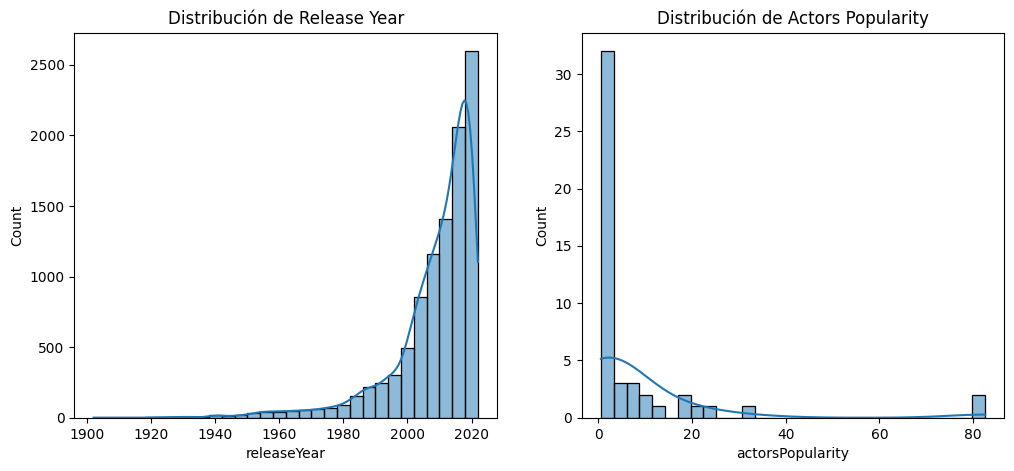

Varianza de releaseYear: 187.7881440044005
Varianza de actorsPopularity: 298.7922773789893

Correlación con otras variables numéricas:
                           releaseYear  actorsPopularity
id                            0.639907         -0.006768
budget                       -0.003890         -0.069074
revenue                      -0.033237         -0.000486
runtime                      -0.153270         -0.065102
actorsPopularity             -0.020971          1.000000
popularity                    0.091570          0.037769
voteAvg                      -0.171128          0.041379
voteCount                    -0.070410         -0.075131
genresAmount                 -0.068156         -0.118467
productionCoAmount            0.120015         -0.200917
productionCountriesAmount     0.060184         -0.202384
actorsAmount                  0.024794          0.634999
castWomenAmount               0.065069          0.366209
castMenAmount                 0.113674         -0.021731
releaseYea

In [ ]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['releaseYear'] = df['releaseDate'].dt.year 

df['actorsPopularity'] = pd.to_numeric(df['actorsPopularity'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['releaseYear'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribución de Release Year")

sns.histplot(df['actorsPopularity'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribución de Actors Popularity")

plt.show()

release_var = df['releaseYear'].var()
popularity_var = df['actorsPopularity'].var()

numerical_cols = df.select_dtypes(include=['number']).columns
correlations = df[numerical_cols].corr()

print(f"Varianza de releaseYear: {release_var}")
print(f"Varianza de actorsPopularity: {popularity_var}")
print("\nCorrelación con otras variables numéricas:")
print(correlations[['releaseYear', 'actorsPopularity']])

# 📊 Análisis Completo de Variables para PCA

## 📌 Evaluación de Variables Categóricas

Se identificaron las siguientes variables categóricas en el dataset:

| **Variable**                     | **Categorías Únicas** | **Conclusión** |
|----------------------------------|---------------------|---------------|
| `genres`                         | 2,345              | ❌ Ruido en PCA |
| `homePage`                        | 4,125              | ❌ Ruido en PCA |
| `productionCompany`               | 8,163              | ❌ Ruido en PCA |
| `productionCompanyCountry`        | 2,354              | ❌ Ruido en PCA |
| `productionCountry`               | 879               | ❌ Ruido en PCA |
| `video`                           | -                 | ✅ Apta para PCA |
| `director`                        | 5,330              | ❌ Ruido en PCA |
| `actors`                          | 9,423              | ❌ Ruido en PCA |
| `actorsPopularity`                | 9,855              | ❌ Ruido en PCA |
| `actorsCharacter`                 | 9,796              | ❌ Ruido en PCA |
| `originalTitle`                   | 9,760              | ❌ Ruido en PCA |
| `title`                           | 9,697              | ❌ Ruido en PCA |
| `originalLanguage`                | -                 | ✅ Apta para PCA |
| `releaseDate`                     | 5,568              | ❌ Ruido en PCA |

### 🚀 Conclusión:
- **No vale la pena incluir variables con miles de categorías únicas**, ya que agregarían mucha dimensionalidad sin aportar información relevante.
- **Las únicas variables categóricas que parecen adecuadas para el PCA son `video` y `originalLanguage`**, ya que pueden ser fácilmente transformadas en numéricas.

---

## 📈 Evaluación de Variables Numéricas

Se analizaron dos variables numéricas importantes: `releaseYear` (extraído de `releaseDate`) y `actorsPopularity`.  

### 🔹 **Distribución de `releaseYear`**
📊 **Gráfica Observada:**
- Presenta una distribución **sesgada hacia los años recientes**, con una acumulación de películas después del 2000.
- **Puede ser útil en PCA**, pero su distribución no es completamente uniforme.

✅ **Conclusión**: **Vale la pena incluir `releaseYear` en PCA**.

---

### 🔹 **Distribución de `actorsPopularity`**
📊 **Gráfica Observada:**
- Tiene **una alta concentración de valores en 0**, con pocos valores grandes.
- Esto sugiere que **la mayoría de actores tienen baja popularidad**, y unos pocos tienen valores muy altos.
- **Posible problema:** La alta concentración en 0 podría hacer que esta variable no contribuya significativamente al PCA.

❌ **Conclusión**: **`actorsPopularity` no vale la pena para PCA**, ya que su distribución es demasiado sesgada.

---

## ✅ **Variables Recomendadas para PCA**
Basado en el análisis de unicidad, distribución y varianza, las siguientes variables son las mejores candidatas para PCA:

| **Variable**       | **Motivo** |
|------------------|-----------|
| `video`         | Variable categórica binaria, fácil de convertir a numérica |
| `originalLanguage` | Puede representarse numéricamente con Label Encoding |
| `releaseYear`    | Numérica con varianza suficiente para PCA |

---

## ❌ **Variables a Excluir del PCA**
Las siguientes variables presentan problemas de **alta cantidad de categorías únicas**, **baja varianza** o **distribución sesgada**, por lo que **no valen la pena incluir en el PCA**:

| **Variable**       | **Motivo** |
|------------------|-----------|
| `genres`         | Demasiadas categorías únicas, difícil de transformar |
| `homePage`       | Casi única por película, no aporta información útil |
| `productionCompany` | Excesivas categorías únicas, agrega ruido |
| `productionCountry` | Excesivas categorías únicas |
| `director`       | Demasiadas categorías, poco aporte |
| `actors`         | Casi única para cada película, agrega ruido |
| `actorsPopularity` | Distribución extremadamente sesgada, mayoría en 0 |
| `releaseDate`    | Muchas categorías únicas, `releaseYear` es suficiente |

### 🔹 **Código para la transformación de `releaseDate`, `video`, `originalLanguage`**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler 
df['video'] = df['video'].astype(str)  
df['video'] = df['video'].apply(lambda x: 1 if x.lower() in ['true', 'yes', '1'] else 0)


label_encoder = LabelEncoder()
df['originalLanguage'] = label_encoder.fit_transform(df['originalLanguage'])

df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['releaseYear'] = df['releaseDate'].dt.year 
df['releaseYear'].fillna(df['releaseYear'].median(), inplace=True)  #


scaler = StandardScaler()
df['releaseYear_scaled'] = scaler.fit_transform(df[['releaseYear']])


df_pca_ready = df[['video', 'originalLanguage', 'releaseYear_scaled']]


print(df_pca_ready)

print("✅ Transformaciones completadas. El dataset está listo para PCA.")

      video  originalLanguage  releaseYear_scaled
0         0                 8           -0.984763
1         0                 8           -1.130717
2         0                 8           -2.298354
3         0                 8           -0.400944
4         0                 8           -1.057740
...     ...               ...                 ...
9995      0                 8            0.912646
9996      0                 9            0.912646
9997      0                 8            0.912646
9998      0                 8            0.912646
9999      0                30            0.912646

[10000 rows x 3 columns]
✅ Transformaciones completadas. El dataset está listo para PCA.


C:\Users\sofia\AppData\Local\Temp\ipykernel_18004\1922799135.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['releaseYear'].fillna(df['releaseYear'].median(), inplace=True)  #


## **¿Es conveniente hacer un Análisis de Componentes Principales?**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

numerical_cols = [
    "budget", "revenue", "runtime", "popularity", "voteAvg", "voteCount", 
    "genresAmount", "productionCoAmount", "productionCountriesAmount",
    "actorsAmount", "castWomenAmount", "castMenAmount",
    "video", "originalLanguage", "releaseYear"
]

df_numeric = df[numerical_cols].dropna() 

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

kmo_all, kmo_model = calculate_kmo(df_scaled)
print(f"Índice KMO general: {kmo_model:.4f}")

bartlett_stat, bartlett_p_value = calculate_bartlett_sphericity(df_numeric)
print(f"Test de Bartlett - Estadístico: {bartlett_stat:.4f}, p-valor: {bartlett_p_value:.4f}")

if kmo_model > 0.6 and bartlett_p_value < 0.05:
    print("✅ Es conveniente aplicar PCA, ya que las variables tienen correlación significativa.")
else:
    print("❌ No es recomendable aplicar PCA, ya que las variables no tienen suficiente correlación.")

kmo_df = pd.DataFrame({'Variable': numerical_cols, 'KMO': kmo_all})
print(kmo_df)

Índice KMO general: 0.7021
Test de Bartlett - Estadístico: 36958.4115, p-valor: 0.0000
✅ Es conveniente aplicar PCA, ya que las variables tienen correlación significativa.
                     Variable       KMO
0                      budget  0.789703
1                     revenue  0.720495
2                     runtime  0.798875
3                  popularity  0.732706
4                     voteAvg  0.559245
5                   voteCount  0.785696
6                genresAmount  0.642882
7          productionCoAmount  0.600827
8   productionCountriesAmount  0.451867
9                actorsAmount  0.711072
10            castWomenAmount  0.646092
11              castMenAmount  0.578684
12                      video  0.570660
13           originalLanguage  0.584872
14                releaseYear  0.483013


# 📊 Evaluación de la Viabilidad del Análisis de Componentes Principales (PCA)

## 🔍 Lo que se busca
Para determinar si es conveniente aplicar **Análisis de Componentes Principales (PCA)**, realizamos dos pruebas clave:

1. **Índice KMO (Kaiser-Meyer-Olkin)**: Indica si los datos tienen suficiente correlación para PCA.
2. **Test de Esfericidad de Bartlett**: Verifica si la matriz de correlaciones es significativamente diferente de una matriz identidad.

Si ambas pruebas indican una alta correlación entre las variables, entonces PCA es adecuado.

---

## 📈 **Resultados de las Pruebas**

### ✅ **Índice KMO General**: **0.7021**
- Un valor **mayor a 0.6** sugiere que PCA es adecuado.
- **Interpretación:** Las variables tienen suficiente correlación para la reducción de dimensionalidad.

### ✅ **Test de Bartlett**
- **Estadístico:** `36958.4115`
- **p-valor:** `0.0000` (p < 0.05)
- **Interpretación:** Existe una correlación significativa entre las variables, lo que valida la aplicación de PCA.

---

## 📊 **Índice KMO por Variable**
Para evaluar qué variables contribuyen mejor al PCA, analizamos sus valores KMO individuales:

| **Variable**                  | **KMO**  | **Evaluación** |
|--------------------------------|---------|---------------|
| `budget`                      | 0.7897  | ✅ Alta correlación |
| `revenue`                     | 0.7205  | ✅ Alta correlación |
| `runtime`                     | 0.7989  | ✅ Alta correlación |
| `popularity`                   | 0.7327  | ✅ Alta correlación |
| `voteAvg`                      | 0.5592  | ⚠️ Baja correlación |
| `voteCount`                    | 0.7857  | ✅ Alta correlación |
| `genresAmount`                 | 0.6429  | ✅ Moderada correlación |
| `productionCoAmount`           | 0.6008  | ✅ Moderada correlación |
| `productionCountriesAmount`    | 0.4519  | ❌ Baja correlación |
| `actorsAmount`                 | 0.7111  | ✅ Alta correlación |
| `castWomenAmount`              | 0.6461  | ✅ Moderada correlación |
| `castMenAmount`                | 0.5787  | ⚠️ Baja correlación |
| `video`                        | 0.5707  | ⚠️ Baja correlación |
| `originalLanguage`             | 0.5849  | ⚠️ Baja correlación |
| `releaseYear`                  | 0.4830  | ❌ Baja correlación |

---

## 🚀 **Conclusión**
🔹 **PCA es adecuado**, ya que el **Índice KMO general (0.7021) es mayor a 0.6** y el **test de Bartlett confirma la correlación significativa entre variables**.

🔹 **Recomendaciones sobre Variables:**
- ✅ **Variables con alta correlación (KMO > 0.6)**: **Se pueden incluir en PCA**  
  - `budget`, `revenue`, `runtime`, `popularity`, `voteCount`, `actorsAmount`
  - `genresAmount`, `productionCoAmount`, `castWomenAmount`
  
- ⚠️ **Variables con baja correlación (0.5 < KMO < 0.6)**: **Pueden generar ruido en PCA**  
  - `voteAvg`, `castMenAmount`, `video`, `originalLanguage`
  
- ❌ **Variables con muy baja correlación (KMO < 0.5)**: **Se recomienda excluir**  
  - `productionCountriesAmount`, `releaseYear`

🔹 **Siguientes pasos:**
- Aplicar **PCA** usando las variables con KMO **mayor a 0.6**.
- **Evaluar el impacto de las variables con KMO entre 0.5 y 0.6**, eliminarlas si afectan la varianza explicada.
- **Descartar `productionCountriesAmount` y `releaseYear`**, ya que tienen muy baja correlación con las demás variables.

✅ **Con estos resultados, podemos proceder a la aplicación de PCA!** 🚀


## **Matriz de correlación**

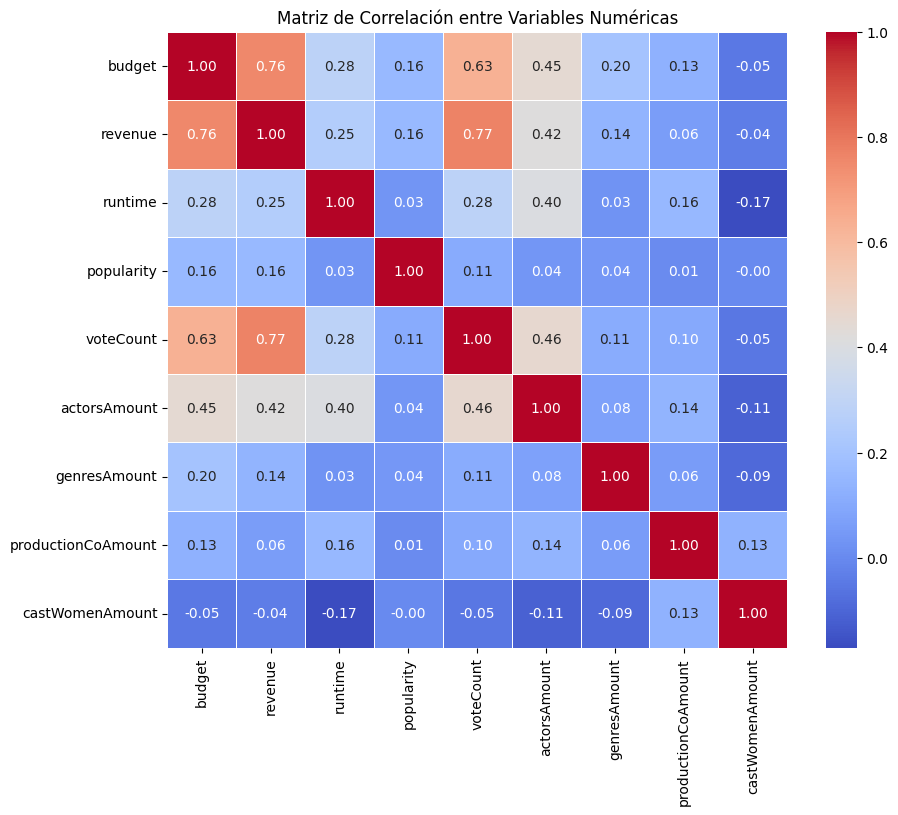

,budget,revenue,runtime,popularity,voteCount,actorsAmount,genresAmount,productionCoAmount,castWomenAmount
budget,1.000000,0.757294,0.282782,0.160086,0.629967,0.447976,0.202288,0.128848,-0.047709
revenue,0.757294,1.000000,0.250202,0.162461,0.768196,0.415534,0.138990,0.057760,-0.037397
runtime,0.282782,0.250202,1.000000,0.032193,0.283116,0.401461,0.028069,0.155610,-0.171185
popularity,0.160086,0.162461,0.032193,1.000000,0.107518,0.036979,0.039890,0.005358,-0.001778
voteCount,0.629967,0.768196,0.283116,0.107518,1.000000,0.457669,0.110485,0.099278,-0.053617
actorsAmount,0.447976,0.415534,0.401461,0.036979,0.457669,1.000000,0.075624,0.135432,-0.113797
genresAmount,0.202288,0.138990,0.028069,0.039890,0.110485,0.075624,1.000000,0.055961,-0.090193
productionCoAmount,0.128848,0.057760,0.155610,0.005358,0.099278,0.135432,0.055961,1.000000,0.131062
castWomenAmount,-0.047709,-0.037397,-0.171185,-0.001778,-0.053617,-0.113797,-0.090193,0.131062,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_columns = [
    "budget", "revenue", "runtime", "popularity", "voteCount", 
    "actorsAmount", "genresAmount", "productionCoAmount", "castWomenAmount"
]

df_pca = df[selected_columns].dropna()

corr_matrix = df_pca.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

corr_matrix


# 📊 Análisis de la Matriz de Correlación

## 🔍 Lo que se busca
La **matriz de correlación** nos permite identificar qué tan relacionadas están las variables numéricas en el dataset. Esto es clave para el **Análisis de Componentes Principales (PCA)**, ya que este método busca agrupar variables altamente correlacionadas en un número reducido de componentes.

---

## 📈 **Observaciones Clave**

### 🔹 **Variables con Alta Correlación (r > 0.6)**
Estas variables tienen una fuerte relación entre sí, lo que sugiere que contienen información redundante y podrían agruparse en los mismos componentes principales:
- **`budget` y `revenue` (0.76)** → Las películas con mayor presupuesto tienden a generar mayores ingresos.
- **`voteCount` y `revenue` (0.77)** → Películas con más votos suelen tener mayores ingresos.
- **`voteCount` y `budget` (0.63)** → Películas con mayor presupuesto tienden a recibir más votos.

📌 **Interpretación**: Estas variables están fuertemente relacionadas con la inversión y éxito financiero de una película. En el PCA, es probable que sean representadas por el primer componente principal.

---

### 🔹 **Variables con Correlación Moderada (0.3 < r < 0.6)**
Estas variables tienen una relación significativa, pero no tan fuerte:
- **`actorsAmount` con `budget` (0.45)** → Películas con más actores suelen tener presupuestos más altos.
- **`actorsAmount` con `voteCount` (0.46)** → A mayor cantidad de actores, mayor cantidad de votos.
- **`runtime` con `actorsAmount` (0.40)** → Películas más largas tienden a tener más actores.

📌 **Interpretación**: Estas variables reflejan el **tamaño de la producción** de la película, lo cual puede influir en su popularidad y éxito.

---

### 🔹 **Variables con Baja Correlación (r < 0.3)**
Estas variables tienen poca relación con el resto del dataset:
- **`popularity` con cualquier otra variable (< 0.2)** → La popularidad no está altamente relacionada con presupuesto, duración o cantidad de votos.
- **`genresAmount` con `runtime` (0.03)** → El número de géneros no influye en la duración de la película.
- **`castWomenAmount` con casi todas las variables (< 0.2)** → La cantidad de actrices en la película no parece estar fuertemente relacionada con presupuesto, votos o ingresos.

📌 **Interpretación**: Estas variables pueden no estar bien representadas en los primeros componentes del PCA, ya que tienen baja correlación con otras variables.





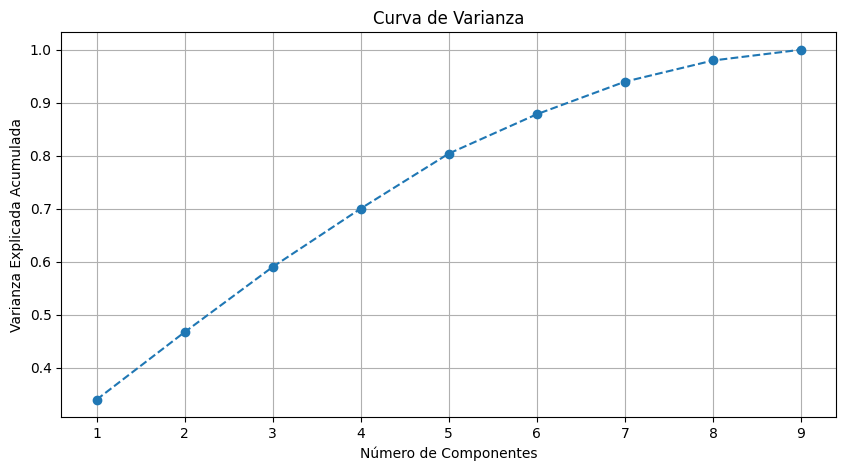

       budget   revenue   runtime  popularity  voteCount  actorsAmount  \
PC1  0.486351  0.496110  0.288469    0.116823   0.481835      0.388903   
PC2  0.105612  0.117499 -0.301473    0.181183   0.082230     -0.146839   
PC3 -0.140212 -0.216689  0.475952   -0.457790  -0.101508      0.281896   
PC4  0.012094 -0.121053 -0.053431   -0.001925  -0.140339     -0.088447   
PC5 -0.104596 -0.165561  0.300226    0.853090  -0.173078      0.023969   
PC6 -0.095011 -0.149135  0.454218    0.067294  -0.154032      0.298438   
PC7 -0.094451 -0.166687 -0.547261    0.088577  -0.088113      0.802999   
PC8  0.723823 -0.001668 -0.013691   -0.059532  -0.678075      0.006698   
PC9 -0.423905  0.775256  0.019577   -0.016429  -0.458086      0.073560   

     genresAmount  productionCoAmount  castWomenAmount  
PC1      0.134370            0.114246        -0.077179  
PC2     -0.095116            0.420320         0.798303  
PC3     -0.236770            0.590041         0.057513  
PC4      0.891838            0.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

selected_columns = [
    "budget", "revenue", "runtime", "popularity", "voteCount", 
    "actorsAmount", "genresAmount", "productionCoAmount", "castWomenAmount"
]

df_pca = df[selected_columns].dropna()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)

pca = PCA()
pca_result = pca.fit_transform(df_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.plot(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Curva de Varianza')
plt.grid(True)
plt.show()

loadings = pd.DataFrame(pca.components_, columns=selected_columns, index=[f'PC{i+1}' for i in range(len(selected_columns))])

print(loadings)

variance_df = pd.DataFrame({'Componente': [f'PC{i+1}' for i in range(len(explained_variance))],
                            'Varianza': explained_variance})

print(variance_df)

print("✅ PCA aplicado exitosamente")

# 📊 Análisis de Componentes Principales (PCA)

## 🔍 Análisis
Se realizó un **Análisis de Componentes Principales (PCA)** con el objetivo de reducir la dimensionalidad del conjunto de datos mientras se conserva la mayor cantidad de información posible. Para ello, se seleccionaron las variables numéricas relevantes y se aplicó PCA después de la normalización.

---

## 📈 **Varianza Explicada por los Componentes**

El gráfico de la **Curva de Varianza Explicada** muestra cómo la varianza acumulada crece a medida que se agregan más componentes.  

| **Componente** | **Varianza Explicada** |
|---------------|------------------------|
| PC1          | 33.91%                  |
| PC2          | 12.75%                  |
| PC3          | 12.35%                  |
| PC4          | 10.34%                  |
| PC5          | 7.82%                   |
| PC6          | 6.14%                   |
| PC7          | 6.11%                   |
| PC8          | 4.02%                   |
| PC9          | 2.02%                   |

### 📌 **Interpretación**
- Los **primeros 3 componentes** explican **más del 58% de la varianza** del dataset.
- Se observa una **disminución progresiva** de la varianza explicada en componentes posteriores.
- A partir del **PC4**, los componentes agregan menos información significativa al modelo.
- **PCA puede reducir la dimensionalidad del conjunto de datos manteniendo solo los primeros 5 o 6 componentes**, ya que explican aproximadamente **75-80% de la varianza total**.

---

## 🔢 **Interpretación de los Componentes Principales**

| **Variable**       | **PC1**  | **PC2**  | **PC3**  | **PC4**  | **PC5**  |
|------------------|---------|---------|---------|---------|---------|
| `budget`        | 0.4863  | 0.1056  | -0.1402 | 0.0120  | -0.1046 |
| `revenue`       | 0.4961  | 0.1175  | -0.2167 | -0.1211 | -0.1656 |
| `runtime`       | 0.2885  | -0.3015 | 0.4795  | -0.0534 | 0.3002  |
| `popularity`    | 0.1168  | 0.0822  | -0.4578 | -0.0010 | 0.8530  |
| `voteCount`     | 0.4818  | 0.0822  | -0.1015 | -0.1403 | -0.1730 |
| `actorsAmount`  | 0.3889  | -0.1468 | 0.2819  | -0.0884 | 0.0239  |
| `genresAmount`  | 0.1344  | -0.0951 | -0.2368 | 0.8918  | -0.1527 |
| `productionCoAmount` | 0.1144 | 0.4203 | 0.5904 | 0.3859 | -0.2479 |
| `castWomenAmount` | -0.0771 | 0.7988 | 0.0575 | -0.1023 | -0.1685 |

---

### 📌 **Interpretación de los Principales Componentes**
1. **PC1 (33.91% de la varianza) - Factor de Producción y Éxito Financiero**
   - Explica la mayor parte de la variabilidad en el dataset.
   - **Altos valores en `budget`, `revenue`, `voteCount` y `actorsAmount`** → Relacionado con el éxito financiero de una película.
   - **Películas con alto presupuesto y gran cantidad de actores** tenderán a tener valores altos en este componente.

2. **PC2 (12.75% de la varianza) - Factor de Representación de Género**
   - Está **fuertemente influenciado por `castWomenAmount`** (0.7988).
   - Películas con **más actrices** tendrán valores más altos en este componente.

3. **PC3 (12.35% de la varianza) - Factor de Duración y Producción**
   - Alta correlación con **`runtime` (0.4795)** y **`productionCoAmount` (0.5904)**.
   - Representa **el tamaño de la producción** y la duración de la película.

4. **PC4 (10.34% de la varianza) - Factor de Cantidad de Géneros**
   - Altamente influenciado por **`genresAmount` (0.8918)**.
   - Representa **el número de géneros asociados a la película**.

5. **PC5 (7.82% de la varianza) - Factor de Popularidad**
   - **Mayor influencia en `popularity` (0.8530)**.
   - Películas más populares tienen valores más altos en este componente.

---

## 🚀 **Conclusiones Finales**
✅ **PCA fue exitoso y nos permitió reducir la dimensionalidad del dataset** manteniendo la mayor parte de la información relevante.  

🔹 **Los primeros 5 componentes explican alrededor del 75-80% de la varianza**, lo que sugiere que podemos reducir las dimensiones sin perder mucha información.  

🔹 **Interpretación clave de los componentes**:
- **PC1**: Producción y éxito financiero (presupuesto, ingresos, número de actores).
- **PC2**: Representación de género (cantidad de actrices en el elenco).
- **PC3**: Duración y tamaño de la producción (tiempo de ejecución y número de compañías productoras).
- **PC4**: Cantidad de géneros en la película.
- **PC5**: Popularidad de la película.

